In [1]:
from thermopy.eos import PengRobinson
from thermopy.properties import residual_gibbs, fugacity_coefficient, residual_enthalpy, residual_entropy
from thermopy.constants import R
import numpy as np
import matplotlib.pyplot as plt

## Residual Gibbs Free Energy
Residual Gibbs free energy ($G^R$) can be calculated either through the Gibbs free energy definition: $G^R = H^R -TS^R$ or through the relationship between $G^R$ and $\phi$: $G^R = RTln\phi$. Plots of $G^R$ through both of these methods can be plotted against reduced pressure to observe their differences due to calculation method.


<function matplotlib.pyplot.show(close=None, block=None)>

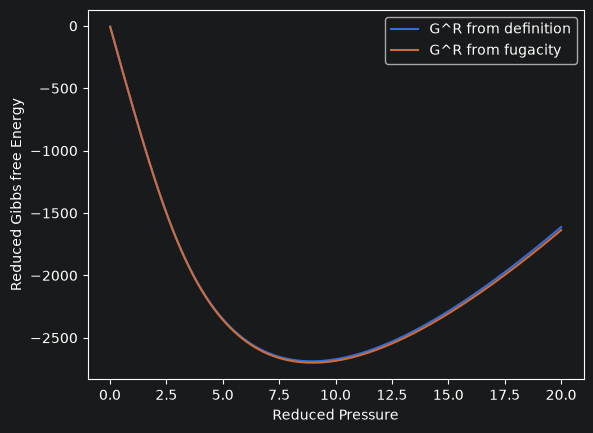

In [4]:
"""
calculated on hydrogen sulphide, EoS object instantiation can be changed for any other available species
"""



PR = PengRobinson("hydrogen sulphide")
T = 500 #[K]
Pr_range = np.linspace(0.01, 20, 1000)
Pc = PR.Pc
Gibbs_phi = []
Gibbs_def = []


for pr in Pr_range:
    p = pr*Pc
    state = PR.solve(T, p)
    state = state[-1]

    gibbs_from_def = residual_gibbs(state, PR, cubicEoS=False)
    fug_coeff = fugacity_coefficient(state, PR, cubicEoS=False)
    gibbs_from_phi = R*T*np.log(fug_coeff)

    Gibbs_phi.append(gibbs_from_phi)
    Gibbs_def.append(gibbs_from_def)

plt.plot(Pr_range, Gibbs_def, label="G^R from definition")
plt.plot(Pr_range, Gibbs_phi, label="G^R from fugacity")

plt.xlabel("Reduced Pressure")
plt.ylabel("Reduced Gibbs free Energy")
plt.legend()
plt.show



In [3]:
state = PR.solve(500, 5*Pc)
state = state[-1]

print("Residual Enthalpy " , residual_enthalpy(state, PR, cubicEoS=True))
print("residual entropy ", residual_entropy(state, PR, cubicEoS=True))
print("T*residual entropy ", 500*residual_entropy(state, PR, cubicEoS=True))
print("G^R definition ", residual_gibbs(state, PR))
print("G^R fugacity", R*500*np.log(fugacity_coefficient(state, PR, cubicEoS=True)))


Residual Enthalpy  -8561.775532352794
residual entropy  -12.41281584103824
T*residual entropy  -6206.40792051912
G^R definition  -2348.83588107941
G^R fugacity -2355.3676118336734
